# Fashion Image Retrieval - Demo

Quick end-to-end sanity check: index a handful of images, then run the
5 evaluation queries from the assignment brief. Run `python -m indexer.run_indexing_pipeline`
from a terminal first (or run the equivalent cells below) before running the query cells.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from utils.config import load_config
from indexer.extract_features import run as extract_features
from indexer.build_faiss_index import build_index

cfg = load_config()
# Small smoke test: index just 25 images first to confirm the pipeline runs end to end
extract_features(cfg, limit=25)
build_index(cfg)

c:\Users\haita\anaconda3\envs\fashion-retrieval\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
13:43:31 | extract_features | INFO | Found 25 images to index.
13:43:31 | extract_features | INFO | Found 800 already-indexed images from a previous run - these will be skipped.
13:43:31 | extract_features | INFO | Nothing left to index - all images already done. Delete data/processed/embeddings/ to force a full rerun.
13:43:31 | build_faiss_index | INFO | Built IndexFlatIP FAISS index with 800 vectors (dim=768).


In [2]:
from models.clip_model import ClipEncoder
from retriever.search import search

clip = ClipEncoder(backbone=cfg['models']['clip']['backbone'],
                    pretrained=cfg['models']['clip']['pretrained'],
                    device=cfg['models']['clip']['device'])

eval_queries = [
    'A person in a bright yellow raincoat.',
    'Professional business attire inside a modern office.',
    'Someone wearing a blue shirt sitting on a park bench.',
    'Casual weekend outfit for a city walk.',
    'A red tie and a white shirt in a formal setting.',
]

for q in eval_queries:
    print('=' * 80)
    print(q)
    for r in search(q, cfg, clip, top_k=5):
        print(f'  {r.image_id:<20} final={r.final_score:.3f} clip={r.clip_similarity:.3f} '
              f'color={r.color_match:.3f} cat={r.category_match:.3f} scene={r.scene_match:.3f}')

c:\Users\haita\anaconda3\envs\fashion-retrieval\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
13:43:57 | search | INFO | Parsed query -> colors=['yellow'] categories=['coat', 'raincoat'] pairs=[('yellow', 'raincoat')] scene=None style=formal
INFO:search:Parsed query -> colors=['yellow'] categories=['coat', 'raincoat'] pairs=[('yellow', 'raincoat')] scene=None style=formal


A person in a bright yellow raincoat.


13:43:59 | search | INFO | CLIP recall stage returned 100 candidates.
INFO:search:CLIP recall stage returned 100 candidates.
13:44:00 | search | INFO | Parsed query -> colors=[] categories=[] pairs=[] scene=office style=formal
INFO:search:Parsed query -> colors=[] categories=[] pairs=[] scene=office style=formal


  1ae9cdebd762234889e60f2c0d07a768 final=0.473 clip=0.224 color=1.000 cat=1.000 scene=0.000
  1d28435f6cabcd0654ab3b4f11c15c0c final=0.293 clip=0.214 color=0.500 cat=0.500 scene=0.000
  320e6497373a2f91a108044407c69a9e final=0.284 clip=0.199 color=0.500 cat=0.500 scene=0.000
  bf323c62fb410d71fd36249e30dd15fb final=0.284 clip=0.198 color=0.500 cat=0.500 scene=0.000
  78b70998064ea34d607363c1f332de7a final=0.282 clip=0.195 color=0.500 cat=0.500 scene=0.000
Professional business attire inside a modern office.


13:44:01 | search | INFO | CLIP recall stage returned 100 candidates.
INFO:search:CLIP recall stage returned 100 candidates.
13:44:02 | search | INFO | Parsed query -> colors=['blue'] categories=['shirt'] pairs=[('blue', 'shirt')] scene=park style=formal
INFO:search:Parsed query -> colors=['blue'] categories=['shirt'] pairs=[('blue', 'shirt')] scene=park style=formal


...

  a2b5ec83b7656e331622ac3c00606161 final=0.374 clip=0.201 color=0.500 cat=0.500 scene=0.887
  cd35a2d7fa74324fb80a0c0d4a55bf6b final=0.367 clip=0.233 color=0.500 cat=0.500 scene=0.637
  2c72aa2fceaf703ccb2f8573d09a1d94 final=0.347 clip=0.211 color=0.500 cat=0.500 scene=0.560
  e8a9349ee53c9e5bfd21102e8b6b52f9 final=0.344 clip=0.172 color=0.500 cat=0.500 scene=0.748
  a9c817161fda6df41766dfe80e939c6b final=0.330 clip=0.164 color=0.500 cat=0.500 scene=0.643
Casual weekend outfit for a city walk.


13:44:04 | search | INFO | CLIP recall stage returned 100 candidates.
INFO:search:CLIP recall stage returned 100 candidates.
13:44:04 | search | INFO | Parsed query -> colors=['white', 'red'] categories=['shirt', 'tie'] pairs=[('white', 'shirt'), ('red', 'tie')] scene=office style=formal
INFO:search:Parsed query -> colors=['white', 'red'] categories=['shirt', 'tie'] pairs=[('white', 'shirt'), ('red', 'tie')] scene=office style=formal


  b8be7863a74a2a7a29af08d41f32e12f final=0.214 clip=0.210 color=0.000 cat=0.000 scene=0.987
  e663c620064af6f5809ee9fef9df4452 final=0.210 clip=0.205 color=0.000 cat=0.000 scene=0.978
  8abeb1e162da88584c77778d51428163 final=0.210 clip=0.202 color=0.000 cat=0.000 scene=0.986
  fb97ca060c9d19671dcafceeb33c3794 final=0.209 clip=0.218 color=0.000 cat=0.000 scene=0.888
  c87fb99e4cbb5a408e8fa1f4d86f9204 final=0.209 clip=0.206 color=0.000 cat=0.000 scene=0.954
A red tie and a white shirt in a formal setting.


13:44:04 | search | INFO | CLIP recall stage returned 100 candidates.
INFO:search:CLIP recall stage returned 100 candidates.


  65e15431d7bd355e3651897d213339c7 final=0.275 clip=0.183 color=0.500 cat=0.500 scene=0.000
  90dedb55e09ac1f7a2fc3e37dfd12f51 final=0.271 clip=0.175 color=0.500 cat=0.500 scene=0.000
  82f2dd35ae34d6010c256e0944a28fd2 final=0.266 clip=0.166 color=0.500 cat=0.500 scene=0.000
  5d561a0a5657ab2e09d65a32ffc1190c final=0.266 clip=0.165 color=0.500 cat=0.500 scene=0.000
  ec791dd926d464f45e3f4e9d78aafd10 final=0.262 clip=0.158 color=0.500 cat=0.500 scene=0.000


15:34:59 | search | INFO | Parsed query -> colors=[] categories=[] pairs=[] scene=office style=formal


INFO:search:Parsed query -> colors=[] categories=[] pairs=[] scene=office style=formal
15:35:01 | search | INFO | CLIP recall stage returned 100 candidates.
INFO:search:CLIP recall stage returned 100 candidates.


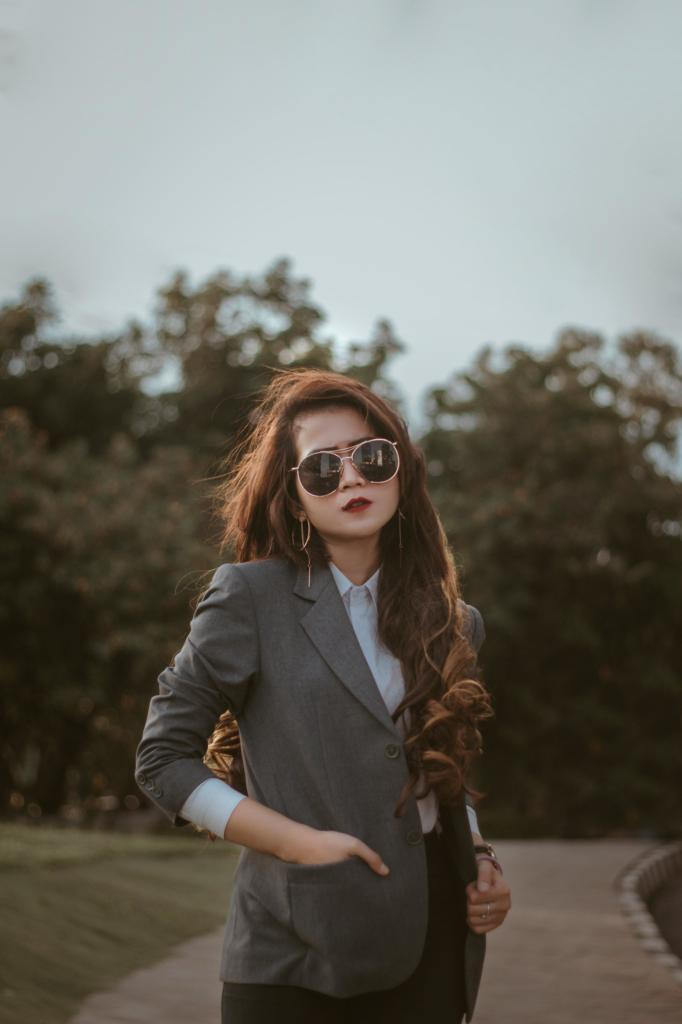

In [8]:
# Optional: visually inspect the top result for one query
from PIL import Image
from retriever.search import search

results = search('Professional business attire inside an office.', cfg, clip, top_k=1)
Image.open(results[0].image_path)